<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

* Natalia Bernal Gutiérrez
* Julián Camilo Carvajal Mellizo


# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

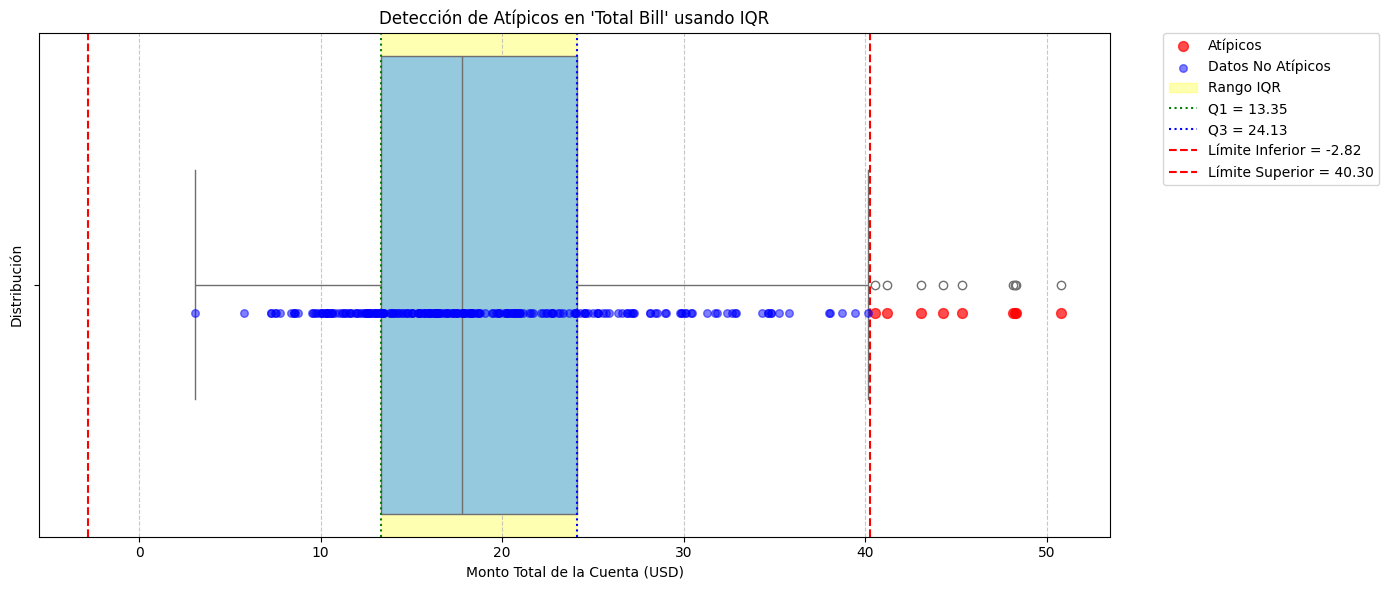

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(14,6)) # Aumentamos el ancho de la figura para la leyenda
sns.boxplot(x=total_bill, color='skyblue')
# Añadimos etiquetas a los puntos para la leyenda
plt.scatter(data_a, [0.05]*len(data_a), color="red", s=50, alpha=0.7, label="Atípicos")
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=30, zorder=5, alpha=0.5, label="Datos No Atípicos")

# Resaltar el Rango Intercuartílico (IQR)
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
# Añadir líneas para Q1 y Q3
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
# Añadir líneas para los límites del IQR (cambiado a rojo según tu ejemplo)
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite Inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite Superior = {lim_sup:.2f}')

plt.xlabel("Monto Total de la Cuenta (USD)") # Nombre del eje X
plt.ylabel("Distribución") # Nombre del eje Y (arbitrario para un boxplot horizontal)
plt.title("Detección de Atípicos en 'Total Bill' usando IQR") # Título para mayor claridad
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Movemos la leyenda a la derecha del gráfico
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado
plt.show()

Todos los valores atípicos son valores altos, lo que indica que cuentas excesivamente costosas no son comunes. Por otro lado, el límite inferior es más corto que el superior y no se notan atípicos, lo que podría indicar que existe un monto mínimo de consumo.





# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

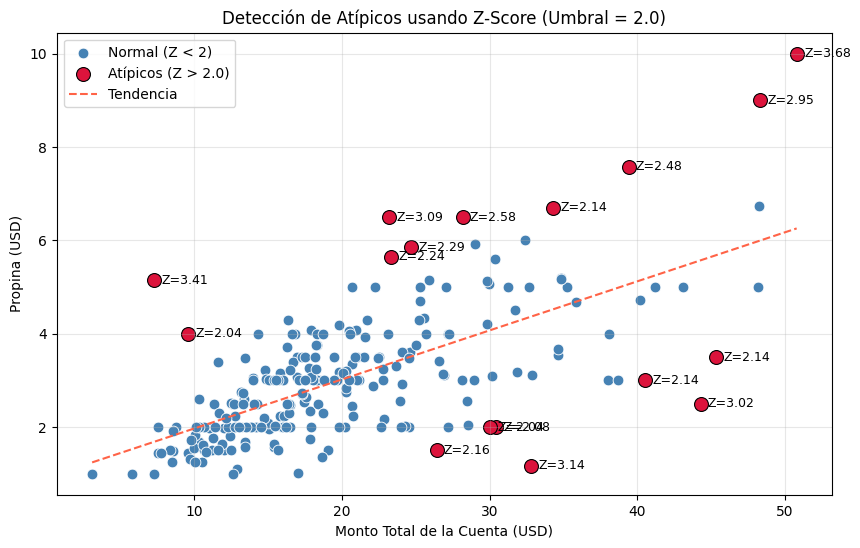

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats # Para calcular el Z-score fácilmente

# 1. Cargar datos
tips = sns.load_dataset("tips")
x = tips["total_bill"]
y = tips["tip"]

# 2. Calcular la línea de tendencia y los residuales
m, b = np.polyfit(x, y, 1)
y_pred = m * x + b
residuales = y - y_pred

# 3. Calcular el Z-Score de los residuales
# El Z-score nos dice qué tan lejos está cada punto de la línea en unidades de desviación estándar
z_scores = np.abs(stats.zscore(residuales))

# Definimos el umbral (Threshold)
# 2.0 es estándar para detectar variaciones, 3.0 es para atípicos muy severos
umbral = 2.0
atipicos = z_scores > umbral

# 4. Graficar
plt.figure(figsize=(10, 6))

# Puntos normales
sns.scatterplot(x=x[~atipicos], y=y[~atipicos], color="steelblue", label="Normal (Z < 2)", s=60)

# Puntos atípicos detectados por Z-Score
sns.scatterplot(x=x[atipicos], y=y[atipicos], color="crimson", label=f"Atípicos (Z > {umbral})", s=100, edgecolor="black")

# Línea de tendencia
x_range = np.linspace(x.min(), x.max(), 100)
plt.plot(x_range, m * x_range + b, color="tomato", linestyle="--", label="Tendencia")

# 5. Anotar los Z-scores en los puntos más extremos para ver el cálculo
for i in np.where(atipicos)[0]:
    plt.text(x.iloc[i]+0.5, y.iloc[i], f"Z={z_scores[i]:.2f}", fontsize=9, verticalalignment='center')

plt.title(f"Detección de Atípicos usando Z-Score (Umbral = {umbral})")
plt.xlabel("Monto Total de la Cuenta (USD)")
plt.ylabel("Propina (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Existe una correlación positiva clara entre el monto de la cuenta y la propina. Esto significa que, por lo general, a medida que el cliente gasta más en su consumo, el monto de la propina también aumenta. Además, el monto de la propina varia a medida que aumenta el monto total de la cuenta.


# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

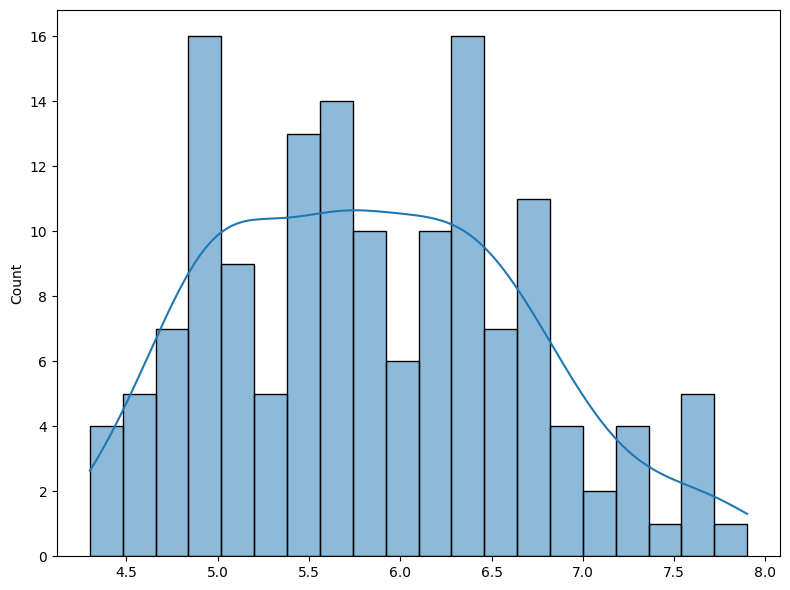

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True)
plt.tight_layout()
plt.show()


# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

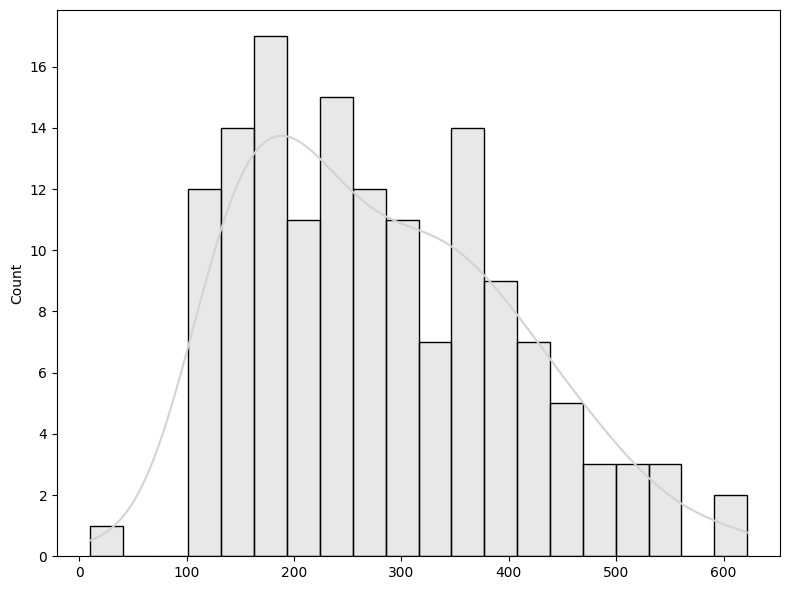

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(8,6))
sns.histplot(x=x, bins=20, kde=True, color="lightgray")
plt.scatter(x[data_b], np.zeros_like(x[data_b]), color="red", s=50, marker=" ")
plt.tight_layout()
plt.show()


# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

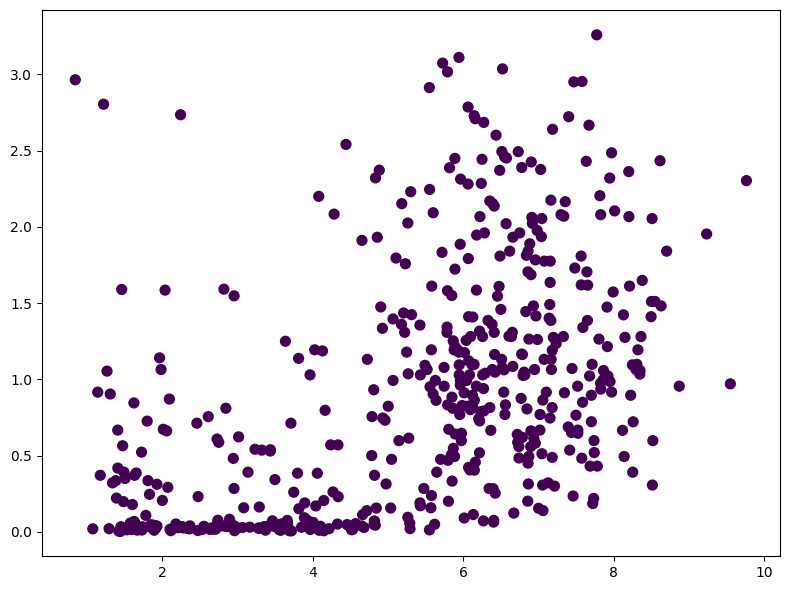

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50)
plt.tight_layout()
plt.show()
